# **Day 83: Model Monitoring and Data Drift**
*Module 12 - Trustworthy ML and MLOps*

A deployed model starts to degrade the moment the world changes: a new sensor calibration, a drought year, new crop varieties, a software update in the preprocessing chain. Usually **no labels** arrive quickly to tell us. **Monitoring** watches inputs, outputs and (when available) performance, and raises alarms before bad predictions cause harm.

> After deployment, the world keeps changing. Monitoring checks input data and predictions for drift and alerts us when the model may need retraining.
>
> *Example:* If a new sensor version makes images slightly brighter, monitoring detects the shift before the map quality quietly degrades.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import jensenshannon
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
rng = np.random.default_rng(83)

## **1. A Deployed Model and a Changing World**
Monthly batches of pixels classified by a crop/non-crop model. Over 24 months we inject realistic problems:
- months 8-10: a **sensor recalibration** (+0.03 in the red band) -> covariate drift that **hurts** accuracy
- months 14-16: a **drought** (lower NIR for crops) -> concept-like drift that hurts accuracy
- month 20: a **pipeline bug** fills 15% of a band with zeros -> data-quality problem
- months 4-5: more **water** pixels in the monsoon -> harmless drift (prior shift the model handles)

In [2]:
features = ["blue", "red", "nir", "swir"]
def batch(month, n=2000, r=rng):
    crop_frac = 0.5 if month not in (4, 5) else 0.35
    crop = r.random(n) < crop_frac
    blue = np.where(crop, r.normal(0.05, 0.01, n), r.normal(0.09, 0.02, n)); red = np.where(crop, r.normal(0.06, 0.015, n), r.normal(0.12, 0.03, n))
    nir = np.where(crop, r.normal(0.35, 0.05, n), r.normal(0.22, 0.05, n)); swir = np.where(crop, r.normal(0.18, 0.03, n), r.normal(0.25, 0.04, n))
    if month in (4, 5): water = r.random(n) < 0.15; nir[water & ~crop] = r.normal(0.03, 0.01, (water & ~crop).sum()); swir[water & ~crop] = 0.02
    if 8 <= month <= 10: red = red + 0.03                                             # sensor recalibration
    if 14 <= month <= 16: nir = np.where(crop, nir - 0.09, nir)                       # drought stress
    df = pd.DataFrame({"blue": blue, "red": red, "nir": nir, "swir": swir, "crop": crop.astype(int)})
    if month == 20: df.loc[r.random(n) < 0.15, "swir"] = 0.0                         # pipeline bug
    return df
reference = batch(0, n=6000)
model = HistGradientBoostingClassifier(random_state=0).fit(reference[features], reference.crop)
months = list(range(1, 25)); batches = {m: batch(m) for m in months}

## **2. Data-Quality Checks (Cheapest, Catch the Most Bugs)**
Before any statistics: schema, missing values, ranges, constant/zero rates.

In [3]:
def quality_checks(df, ref):
    issues = []
    for c in features:
        zero_rate = (df[c] == 0).mean(); ref_zero = (ref[c] == 0).mean()
        if df[c].isna().mean() > 0.01: issues.append(f"{c}: {df[c].isna().mean():.1%} missing")
        if zero_rate > ref_zero + 0.02: issues.append(f"{c}: {zero_rate:.1%} exact zeros (reference {ref_zero:.1%})")
        lo, hi = ref[c].quantile([0.001, 0.999])
        out = ((df[c] < lo - 0.1) | (df[c] > hi + 0.1)).mean()
        if out > 0.01: issues.append(f"{c}: {out:.1%} far outside the reference range")
    return issues
for m in months:
    iss = quality_checks(batches[m], reference)
    if iss: print(f"month {m:>2}: {iss}")

month 20: ['swir: 16.3% exact zeros (reference 0.0%)']


## **3. Input Drift Statistics**

| Statistic | Type | Rule of thumb |
|---|---|---|
| **PSI** (Population Stability Index) $=\sum_b (p_b - q_b)\ln\frac{p_b}{q_b}$ over bins | univariate | < 0.1 stable, 0.1-0.25 moderate, > 0.25 major shift |
| Kolmogorov-Smirnov test | univariate | p-value (with large n, tiny shifts become "significant") |
| Jensen-Shannon distance (Day 12) | univariate | 0 = identical, 1 = disjoint (base 2) |
| **Domain classifier AUC** (Day 79) | multivariate | 0.5 = no detectable shift |

In [4]:
def psi(ref, cur, bins=10):
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1))); edges[0], edges[-1] = -np.inf, np.inf
    p = np.histogram(ref, edges)[0] / len(ref) + 1e-6; q = np.histogram(cur, edges)[0] / len(cur) + 1e-6
    return float(np.sum((q - p) * np.log(q / p)))
def domain_auc(ref, cur):
    X = pd.concat([ref[features], cur[features]]); d = np.r_[np.zeros(len(ref)), np.ones(len(cur))]
    return cross_val_score(RandomForestClassifier(100, max_depth=6, n_jobs=-1, random_state=0), X, d, cv=3, scoring="roc_auc").mean()

ref_sample = reference.sample(2000, random_state=0)
rows = []
for m in months:
    cur = batches[m]; row = {"month": m}
    for c in features:
        row[f"PSI_{c}"] = psi(ref_sample[c], cur[c])
    row["max_PSI"] = max(row[f"PSI_{c}"] for c in features)
    row["KS_p_min"] = min(stats.ks_2samp(ref_sample[c], cur[c]).pvalue for c in features)
    row["domain_AUC"] = domain_auc(ref_sample, cur)
    p_cur = model.predict_proba(cur[features])[:, 1]; p_ref = model.predict_proba(ref_sample[features])[:, 1]
    row["pred_positive_rate"] = (p_cur > 0.5).mean(); row["mean_confidence"] = np.maximum(p_cur, 1 - p_cur).mean()
    row["JS_pred"] = jensenshannon(np.histogram(p_ref, 20, (0, 1))[0] + 1e-6, np.histogram(p_cur, 20, (0, 1))[0] + 1e-6, base=2)
    row["accuracy"] = model.score(cur[features], cur.crop)                           # only known later, when labels arrive
    rows.append(row)
mon = pd.DataFrame(rows).set_index("month")
mon[["max_PSI", "domain_AUC", "pred_positive_rate", "mean_confidence", "accuracy"]].round(3)

,max_PSI,domain_AUC,pred_positive_rate,mean_confidence,accuracy
month,,,,,
1,0.012,0.508,0.489,0.997,0.992
2,0.013,0.504,0.478,0.997,0.990
3,0.018,0.487,0.495,0.997,0.994
4,0.098,0.596,0.364,0.995,0.990
5,0.154,0.619,0.334,0.997,0.993
6,0.022,0.516,0.503,0.997,0.992
7,0.019,0.519,0.498,0.997,0.994
8,1.332,0.828,0.448,0.985,0.948
9,2.166,0.834,0.448,0.986,0.956


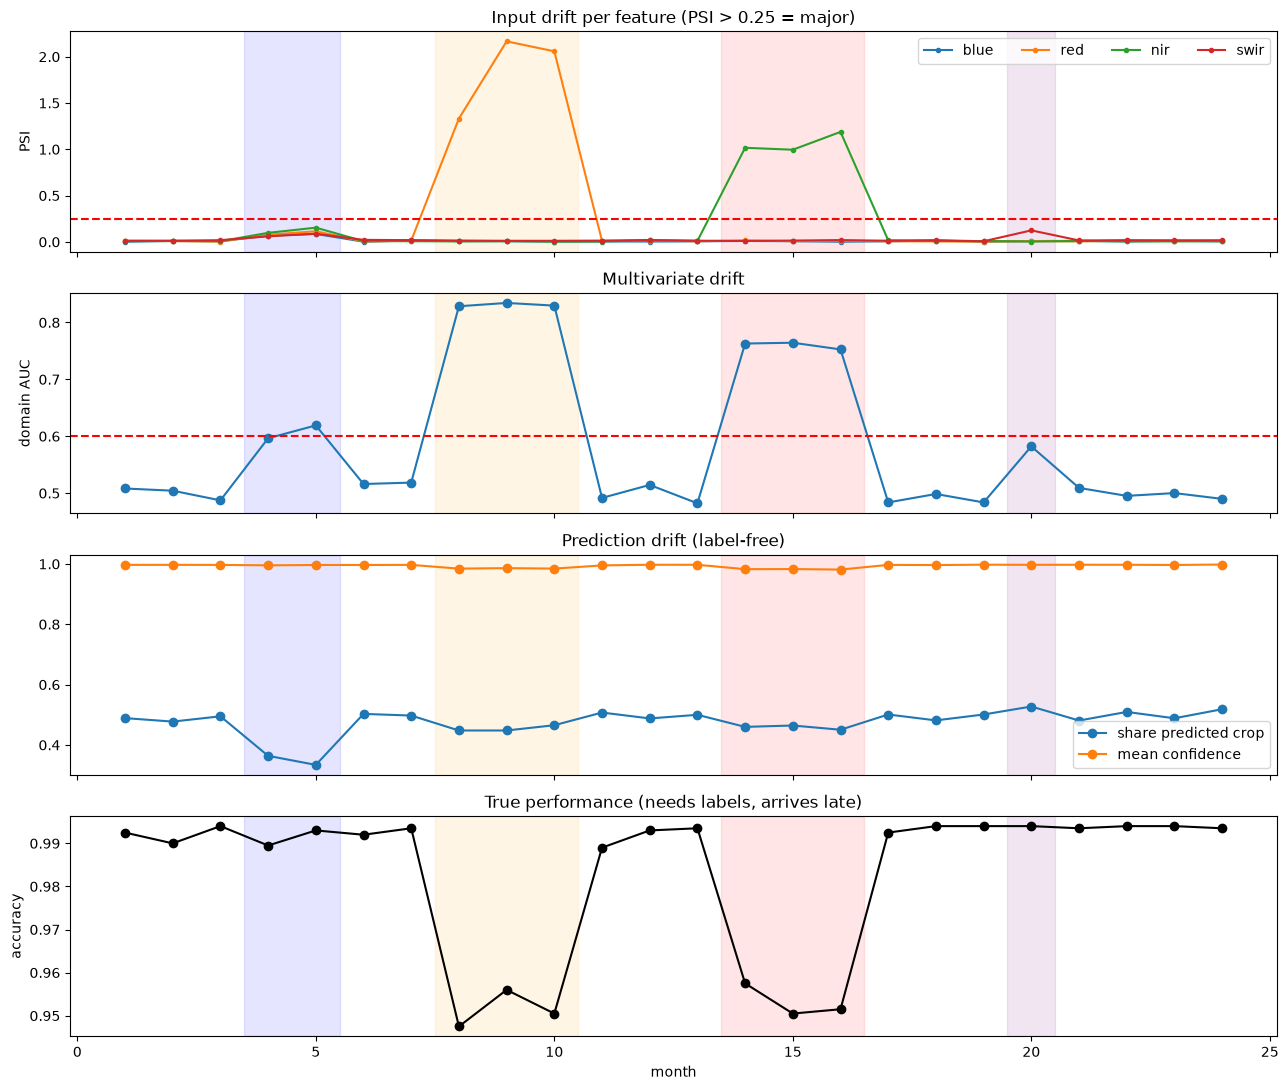

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for c in features: axes[0].plot(mon.index, mon[f"PSI_{c}"], "o-", label=c, ms=3)
axes[0].axhline(0.25, c="r", ls="--"); axes[0].set(ylabel="PSI", title="Input drift per feature (PSI > 0.25 = major)"); axes[0].legend(ncol=4)
axes[1].plot(mon.index, mon.domain_AUC, "o-"); axes[1].axhline(0.6, c="r", ls="--"); axes[1].set(ylabel="domain AUC", title="Multivariate drift")
axes[2].plot(mon.index, mon.pred_positive_rate, "o-", label="share predicted crop"); axes[2].plot(mon.index, mon.mean_confidence, "o-", label="mean confidence"); axes[2].legend(); axes[2].set(title="Prediction drift (label-free)")
axes[3].plot(mon.index, mon.accuracy, "o-", c="k"); axes[3].set(ylabel="accuracy", title="True performance (needs labels, arrives late)", xlabel="month")
for ax in axes:
    for a, b, col in [(4, 5, "b"), (8, 10, "orange"), (14, 16, "red"), (20, 20, "purple")]: ax.axvspan(a - 0.5, b + 0.5, color=col, alpha=0.1)
plt.tight_layout(); plt.show()

- The **monsoon water** (blue band of the plot) causes drift but accuracy stays high: **not all drift is harmful**.
- The **recalibration** and **drought** periods show drift **and** an accuracy drop; prediction drift and falling confidence flag them before labels arrive.
- The **pipeline bug** is caught by the cheap zero-rate check.

## **4. Sequential Change Detection: CUSUM**
Monthly thresholds can miss slow drifts. **CUSUM** accumulates small deviations from a target and alarms when the cumulative sum exceeds a threshold.

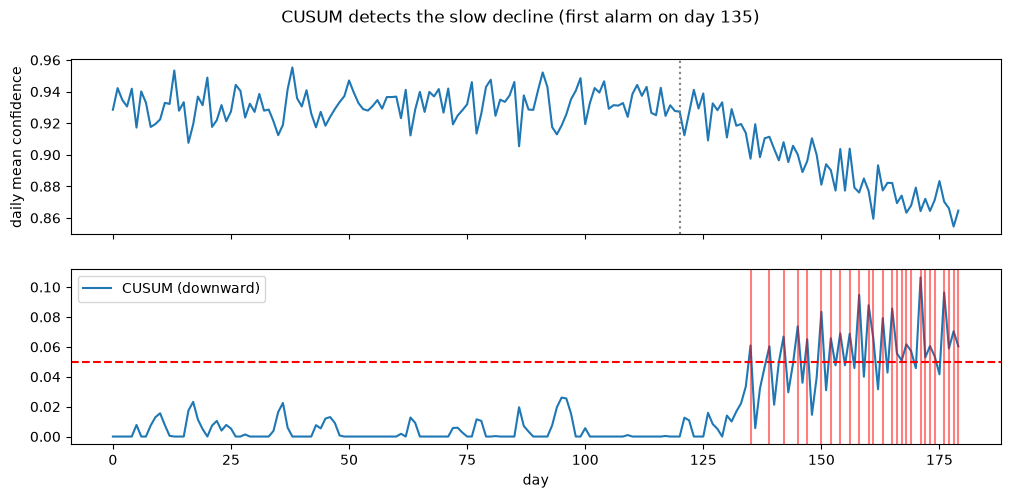

In [6]:
def cusum(x, target, k, h):
    s_hi = s_lo = 0.0; alarms, path = [], []
    for i, v in enumerate(x):
        s_hi = max(0, s_hi + (v - target - k)); s_lo = max(0, s_lo + (target - v - k)); path.append((s_hi, s_lo))
        if s_hi > h or s_lo > h: alarms.append(i); s_hi = s_lo = 0.0
    return alarms, np.array(path)
daily_conf = np.r_[rng.normal(0.93, 0.01, 120), np.linspace(0.93, 0.86, 60) + rng.normal(0, 0.01, 60)]   # slow degradation from day 120
alarms, path = cusum(daily_conf, target=0.93, k=0.005, h=0.05)
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(daily_conf); axes[0].axvline(120, c="grey", ls=":"); axes[0].set_ylabel("daily mean confidence")
axes[1].plot(path[:, 1], label="CUSUM (downward)"); axes[1].axhline(0.05, c="r", ls="--")
for a in alarms: axes[1].axvline(a, c="r", alpha=0.5)
axes[1].legend(); axes[1].set_xlabel("day"); plt.suptitle(f"CUSUM detects the slow decline (first alarm on day {alarms[0] if alarms else None})"); plt.show()

## **5. Performance Monitoring With Delayed Labels**
In remote sensing, labels come from periodic field campaigns or photo-interpretation of a **probability sample** (Day 88). Plan a small monthly/seasonal **audit sample** and track accuracy with confidence intervals; trigger retraining when the CI falls below the requirement.

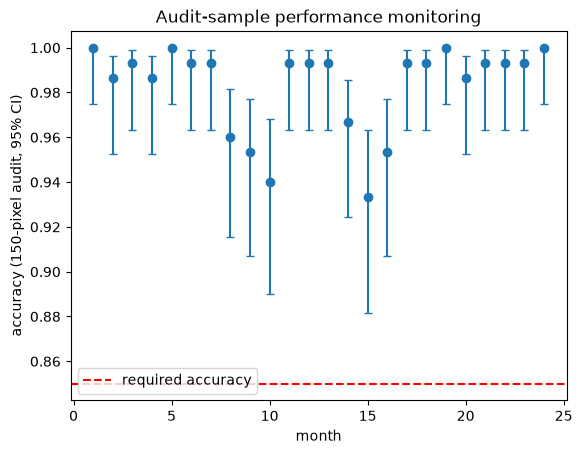

In [7]:
from statsmodels.stats.proportion import proportion_confint
audit = []
for m in months:
    s = batches[m].sample(150, random_state=m); acc_ = model.score(s[features], s.crop); lo, hi = proportion_confint(int(acc_ * 150), 150, method="wilson")
    audit.append((m, acc_, lo, hi))
audit = np.array(audit)
plt.errorbar(audit[:, 0], audit[:, 1], yerr=[audit[:, 1] - audit[:, 2], audit[:, 3] - audit[:, 1]], fmt="o", capsize=3)
plt.axhline(0.85, c="r", ls="--", label="required accuracy"); plt.xlabel("month"); plt.ylabel("accuracy (150-pixel audit, 95% CI)"); plt.legend(); plt.title("Audit-sample performance monitoring"); plt.show()

## **6. Retraining Policies and the MLOps Loop**
1. **Scheduled** retraining (e.g. every season) with the newest labelled data.
2. **Triggered** retraining when monitored performance or drift crosses a threshold.
3. Always evaluate the new model against the current one on recent labelled data (**champion vs challenger**), deploy gradually, keep rollback (Day 82).
4. Fix **root causes** first: a recalibrated sensor needs harmonisation; a pipeline bug needs a code fix, not retraining.

In [8]:
recal = pd.concat([batches[m] for m in (8, 9)])
challenger = HistGradientBoostingClassifier(random_state=0).fit(pd.concat([reference, recal])[features], pd.concat([reference, recal]).crop)
print(f"month 10 accuracy: champion {model.score(batches[10][features], batches[10].crop):.3f} | challenger retrained with months 8-9 {challenger.score(batches[10][features], batches[10].crop):.3f}")
print(f"month 3 (normal) : champion {model.score(batches[3][features], batches[3].crop):.3f} | challenger {challenger.score(batches[3][features], batches[3].crop):.3f}")

month 10 accuracy: champion 0.951 | challenger retrained with months 8-9 0.989
month 3 (normal) : champion 0.994 | challenger 0.990


# **Part 2: Going Deeper - Which Drift Matters?**

Drift in a feature the model does not rely on is harmless; small drift in a critical feature can be disastrous. Weight drift by **feature importance**, or monitor drift of the model's **outputs and uncertainty** (which integrates everything). Too many alerts cause **alert fatigue**: tune thresholds on historical data, require persistence (k consecutive alarms), and route alerts to an owner.

In [9]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(model, ref_sample[features], ref_sample.crop, n_repeats=5, random_state=0).importances_mean
imp = pd.Series(imp / imp.sum(), index=features)
mon["importance_weighted_PSI"] = sum(mon[f"PSI_{c}"] * imp[c] for c in features)
print("feature importance shares:", imp.round(3).to_dict())
print(mon[["max_PSI", "importance_weighted_PSI", "accuracy"]].corr(method="spearman").round(2))

feature importance shares: {'blue': 0.452, 'red': 0.329, 'nir': 0.153, 'swir': 0.066}
                         max_PSI  importance_weighted_PSI  accuracy
max_PSI                     1.00                     0.84     -0.57
importance_weighted_PSI     0.84                     1.00     -0.56
accuracy                   -0.57                    -0.56      1.00


## **Practice Problems**
1. Compute PSI with 5 and 20 bins for the red band in month 9. How sensitive is PSI to binning?
2. Implement the **Page-Hinkley** test and compare its detection delay with CUSUM on `daily_conf`.
3. Write a function `monitoring_report(month)` that prints a one-paragraph status (OK / WARNING / CRITICAL) from the quality checks, max PSI, domain AUC and prediction drift.
4. *(Advanced)* Use the domain classifier to find **which** pixels drifted most in month 15 and inspect their feature values.

In [10]:
# Solution 1
for b in [5, 10, 20]: print(f"{b} bins: PSI(red, month 9) = {psi(ref_sample.red, batches[9].red, bins=b):.3f}")
# Solution 2
def page_hinkley(x, delta=0.002, lam=0.03):
    mean, m_t, M = x[0], 0.0, 0.0
    for i, v in enumerate(x[1:], 1):
        mean += (v - mean) / (i + 1); m_t += mean - v - delta; M = min(M, m_t)       # detects decreases
        if m_t - M > lam: return i
    return None
print("Page-Hinkley first alarm on day:", page_hinkley(daily_conf), "| CUSUM:", alarms[0] if alarms else None)
# Solution 3
def monitoring_report(m):
    q = quality_checks(batches[m], reference); r = mon.loc[m]
    level = "CRITICAL" if q or r.max_PSI > 0.25 else ("WARNING" if r.max_PSI > 0.1 or r.domain_AUC > 0.6 else "OK")
    return f"month {m}: {level} | quality issues: {q or 'none'} | max PSI {r.max_PSI:.2f} | domain AUC {r.domain_AUC:.2f} | predicted crop share {r.pred_positive_rate:.2f}"
for m in [3, 5, 9, 15, 20]: print(monitoring_report(m))

5 bins: PSI(red, month 9) = 1.318
10 bins: PSI(red, month 9) = 2.166
20 bins: PSI(red, month 9) = 2.169
Page-Hinkley first alarm on day: 36 | CUSUM: 135
month 3: OK | quality issues: none | max PSI 0.02 | domain AUC 0.49 | predicted crop share 0.49
month 5: WARNING | quality issues: none | max PSI 0.15 | domain AUC 0.62 | predicted crop share 0.33
month 9: CRITICAL | quality issues: none | max PSI 2.17 | domain AUC 0.83 | predicted crop share 0.45
month 15: CRITICAL | quality issues: none | max PSI 1.00 | domain AUC 0.76 | predicted crop share 0.46
month 20: CRITICAL | quality issues: ['swir: 16.3% exact zeros (reference 0.0%)'] | max PSI 0.12 | domain AUC 0.58 | predicted crop share 0.53


Problem 4 is an **open exercise**. Fit the domain classifier from Section 5 on month 0 vs month 15, sort the month-15 pixels by `predict_proba[:, 1]` and compare the feature means of the top 5% with the reference month.

## **Key References**
- Gama, J., Zliobaite, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014). A survey on concept drift adaptation. *ACM Computing Surveys*, 46(4), 44.
- Rabanser, S., Gunnemann, S., & Lipton, Z. C. (2019). Failing loudly: An empirical study of methods for detecting dataset shift. *NeurIPS 32*.
- Page, E. S. (1954). Continuous inspection schemes. *Biometrika*, 41(1-2), 100-115 (CUSUM).
- Lu, J. et al. (2019). Learning under concept drift: A review. *IEEE TKDE*, 31(12), 2346-2363.
- Shankar, S. et al. (2024). Operationalizing machine learning: An interview study. arXiv:2209.09125.
- Roy, D. P. et al. (2016). Characterization of Landsat-7 to Landsat-8 reflective wavelength and normalized difference vegetation index continuity. *Remote Sensing of Environment*, 185, 57-70 (sensor harmonisation).